# Analyse des illustrations classées cuivre

**Projet** : Gallica Images — Classification gravures sur bois vs cuivre  
**Date**   : Avril 2026

Ce notebook analyse les résultats des modèles v1 et v2 appliqués aux
9200 résultats de similarité Salomon. Il produit des visualisations
destinées à Céline Bohnert pour valider manuellement les illustrations
classées cuivre.

**Entrée**  : `resultats/csv/salomon_enrichi_segmente.csv`  
**Sortie**  : `resultats/Validation_cuivre_bois/Stats_bois_cuivre_recherche/bois_cuivre_recherche_apres_segmentation/*.png`

---


## 1. Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

CHEMIN_CSV = "../../resultats/csv/salomon_enrichi_segmente.csv"
DOSSIER_VIZ = "../../resultats/Validation_cuivre_bois/Stats_bois_cuivre_recherche/bois_cuivre_recherche_apres_segmentation"
os.makedirs(DOSSIER_VIZ, exist_ok=True)

df = pd.read_csv(CHEMIN_CSV)
print(f"✓ CSV chargé : {df.shape[0]} lignes")
print(f"  Colonnes IA : {[c for c in df.columns if 'technique_ia' in c]}")

✓ CSV chargé : 8300 lignes
  Colonnes IA : ['technique_ia_v1', 'technique_ia_conf_v1', 'technique_ia_v2', 'technique_ia_conf_v2', 'technique_ia_v3', 'technique_ia_conf_v3']


In [23]:
# ── Filtrage en amont — garder uniquement les estampes ──────
df_complet = df.copy()  # sauvegarde du CSV complet
df = df[df["technique"] == "estampe"].copy().reset_index(drop=True)

print(f"Filtrage appliqué :")
print(f"  CSV complet : {len(df_complet)} résultats")
print(f"  Estampes    : {len(df)} (utilisés pour l'analyse)")
print(f"  Exclus      : {len(df_complet) - len(df)} (photo, peinture, dessin, impression)")

Filtrage appliqué :
  CSV complet : 8300 résultats
  Estampes    : 7079 (utilisés pour l'analyse)
  Exclus      : 1221 (photo, peinture, dessin, impression)


In [1]:
import pandas as pd
df = pd.read_csv("../../resultats/csv/salomon_enrichi_segmente.csv")
print(f"CSV rechargé : {len(df)} résultats")

CSV rechargé : 8300 résultats


In [2]:
# ── Pas de filtrage — toutes les techniques incluses ────────
# (les métadonnées technique de Gallica ne sont pas fiables,
#  beaucoup d'estampes étant étiquetées "photographie")
print(f"Analyse sur le CSV complet : {len(df)} résultats (toutes techniques)")

Analyse sur le CSV complet : 8300 résultats (toutes techniques)


## 2. Statistiques générales

In [3]:
df_cuivre_v1 = df[df["technique_ia_v1"] == "cuivre"].copy()
df_cuivre_v2 = df[df["technique_ia_v2"] == "cuivre"].copy()
df_cuivre_v3 = df[df["technique_ia_v3"] == "cuivre"].copy()

df_accord    = df[(df["technique_ia_v1"] == "cuivre") &
                  (df["technique_ia_v2"] == "cuivre") &
                  (df["technique_ia_v3"] == "cuivre")].copy()

df_v1_seul   = df[(df["technique_ia_v1"] == "cuivre") &
                  (df["technique_ia_v2"] != "cuivre") &
                  (df["technique_ia_v3"] != "cuivre")].copy()
df_v2_seul   = df[(df["technique_ia_v2"] == "cuivre") &
                  (df["technique_ia_v1"] != "cuivre") &
                  (df["technique_ia_v3"] != "cuivre")].copy()
df_v3_seul   = df[(df["technique_ia_v3"] == "cuivre") &
                  (df["technique_ia_v1"] != "cuivre") &
                  (df["technique_ia_v2"] != "cuivre")].copy()

print("=" * 50)
print("STATISTIQUES GÉNÉRALES")
print("=" * 50)
print(f"  Total résultats         : {len(df):,}")
print(f"  Cuivres v1              : {len(df_cuivre_v1)}")
print(f"  Cuivres v2              : {len(df_cuivre_v2)}")
print(f"  Cuivres v3              : {len(df_cuivre_v3)}")
print(f"  Accord v1 + v2 + v3     : {len(df_accord)} — cas les plus certains")
print(f"  Détectés par v1 seul    : {len(df_v1_seul)}")
print(f"  Détectés par v2 seul    : {len(df_v2_seul)}")
print(f"  Détectés par v3 seul    : {len(df_v3_seul)}")
print(f"  Pages Salomon concernées: {df_accord['salomon_page'].nunique()}")

STATISTIQUES GÉNÉRALES
  Total résultats         : 8,300
  Cuivres v1              : 1671
  Cuivres v2              : 1603
  Cuivres v3              : 2465
  Accord v1 + v2 + v3     : 1278 — cas les plus certains
  Détectés par v1 seul    : 24
  Détectés par v2 seul    : 27
  Détectés par v3 seul    : 566
  Pages Salomon concernées: 157


In [8]:
import re, os

# ── Tableau de validation — désaccords (CSV COMPLET, sauvegarde persistante) ──
df_desaccord = df[
    ~((df["technique_ia_v1"] == df["technique_ia_v2"]) &
      (df["technique_ia_v2"] == df["technique_ia_v3"]))
].copy()

df_desaccord = df_desaccord.drop_duplicates(subset=["link"])
df_desaccord = df_desaccord.sort_values("technique_ia_conf_v3", ascending=False)
print(f"Cas de désaccord entre versions : {len(df_desaccord)}")

lignes = ""
for i, row in df_desaccord.iterrows():
    m_ark   = re.search(r"ark:/12148/(\w+)", row["link"])
    m_folio = re.search(r"/(f\d+)/", row["link"])
    ark_img = m_ark.group(1) if m_ark else row["result_ark"]
    folio   = m_folio.group(1) if m_folio else ""
    gallica = f"https://gallica.bnf.fr/ark:/12148/{ark_img}/{folio}.item" if folio \
              else f"https://gallica.bnf.fr/ark:/12148/{ark_img}"

    # Identifiant unique et stable de la ligne (pour la sauvegarde)
    cle = f"{ark_img}_{folio}"

    def cell(pred, conf):
        couleur = "#c8e6c9" if pred == "cuivre" else "#ffe0b2"
        return f'<td class="pred" style="background:{couleur}">{pred}<br><small>{conf:.2f}</small></td>'

    titre_csv = str(row['titre']).replace('"', '""')

    lignes += f"""
    <tr data-cle="{cle}" data-titre="{titre_csv}" data-ark="{ark_img}" data-folio="{folio}"
        data-v1="{row['technique_ia_v1']}" data-v2="{row['technique_ia_v2']}" data-v3="{row['technique_ia_v3']}">
      <td class="titre">{row['titre']}<br><small>{row['auteur']} — {row['date']}</small></td>
      {cell(row['technique_ia_v1'], row['technique_ia_conf_v1'])}
      {cell(row['technique_ia_v2'], row['technique_ia_conf_v2'])}
      {cell(row['technique_ia_v3'], row['technique_ia_conf_v3'])}
      <td class="valid">
        <label><input type="radio" name="avis_{cle}" value="bois"> Bois</label><br>
        <label><input type="radio" name="avis_{cle}" value="cuivre"> Cuivre</label><br>
        <label><input type="radio" name="avis_{cle}" value="autre"> Autre</label>
      </td>
      <td class="center"><a href="{gallica}" target="_blank">Gallica →</a></td>
    </tr>"""

html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<title>Validation des désaccords — v1 / v2 / v3 — CSV complet</title>
<style>
  body {{ font-family: Georgia, serif; margin: 30px; color: #2c2c2c; background: #faf8f5; }}
  h1 {{ font-size: 22px; color: #5a3e2b; border-bottom: 2px solid #c89b6a; padding-bottom: 10px; }}
  .sous-titre {{ color: #777; font-size: 14px; margin-bottom: 20px; }}
  table {{ border-collapse: collapse; width: 100%; background: white; }}
  th {{ background: #5a3e2b; color: white; padding: 10px; font-size: 13px; }}
  td {{ padding: 8px; border-bottom: 1px solid #eee; font-size: 12px; vertical-align: middle; }}
  .titre {{ font-weight: bold; max-width: 360px; }}
  .titre small {{ color: #999; font-weight: normal; }}
  .pred {{ text-align: center; font-weight: bold; }}
  .pred small {{ color: #666; font-weight: normal; }}
  .valid {{ font-size: 11px; white-space: nowrap; }}
  .center {{ text-align: center; }}
  a {{ color: #8b5a2b; font-weight: bold; text-decoration: none; }}
  tr.fait {{ background: #f0f7f0; }}
  .barre {{ position: sticky; top: 0; background: #faf8f5; padding: 15px 0;
            z-index: 10; border-bottom: 1px solid #ddd; margin-bottom: 10px; }}
  button {{ background: #5a3e2b; color: white; border: none; padding: 10px 20px;
            font-size: 14px; border-radius: 4px; cursor: pointer; font-family: Georgia, serif; margin-right: 10px; }}
  button:hover {{ background: #7a5638; }}
  .reset {{ background: #999; }}
  #compteur {{ margin-left: 5px; color: #777; font-size: 13px; }}
</style>
</head>
<body>
  <h1>Validation des désaccords entre versions (toutes techniques)</h1>
  <p class="sous-titre">
    {len(df_desaccord)} illustrations où les trois versions ne sont pas unanimes —
    analyse sur le corpus complet sans filtre de technique.<br>
    Fond <span style="background:#c8e6c9">vert</span> = cuivre,
    <span style="background:#ffe0b2">orange</span> = bois.
    Vos choix sont <b>sauvegardés automatiquement</b> — vous pouvez fermer et revenir, ils seront conservés.
  </p>
  <div class="barre">
    <button onclick="telecharger()">⬇ Télécharger mes réponses (CSV)</button>
    <button class="reset" onclick="reinitialiser()">Tout effacer</button>
    <span id="compteur"></span>
  </div>
  <table>
    <thead>
      <tr>
        <th>Titre</th>
        <th>v1</th><th>v2</th><th>v3</th>
        <th>Votre avis</th><th>Source</th>
      </tr>
    </thead>
    <tbody>{lignes}
    </tbody>
  </table>

<script>
  const STORAGE_KEY = 'validation_celine_complet';

  // Charger les réponses sauvegardées
  function charger() {{
    const data = localStorage.getItem(STORAGE_KEY);
    return data ? JSON.parse(data) : {{}};
  }}

  // Sauvegarder
  function sauver(reponses) {{
    localStorage.setItem(STORAGE_KEY, JSON.stringify(reponses));
    majCompteur(reponses);
  }}

  function majCompteur(reponses) {{
    document.getElementById('compteur').textContent =
      Object.keys(reponses).length + ' / {len(df_desaccord)} réponse(s) enregistrée(s)';
  }}

  // Restaurer l'état au chargement de la page
  window.addEventListener('DOMContentLoaded', () => {{
    const reponses = charger();
    for (const cle in reponses) {{
      const radio = document.querySelector(
        'input[name="avis_' + cle + '"][value="' + reponses[cle].avis + '"]');
      if (radio) {{
        radio.checked = true;
        radio.closest('tr').classList.add('fait');
      }}
    }}
    majCompteur(reponses);
  }});

  // Enregistrer à chaque coche
  document.querySelectorAll('input[type=radio]').forEach(radio => {{
    radio.addEventListener('change', e => {{
      const tr = e.target.closest('tr');
      const cle = tr.dataset.cle;
      const reponses = charger();
      reponses[cle] = {{
        titre : tr.dataset.titre,
        ark   : tr.dataset.ark,
        folio : tr.dataset.folio,
        v1    : tr.dataset.v1,
        v2    : tr.dataset.v2,
        v3    : tr.dataset.v3,
        avis  : e.target.value
      }};
      sauver(reponses);
      tr.classList.add('fait');
    }});
  }});

  function telecharger() {{
    const reponses = charger();
    let csv = 'titre,ark,folio,v1,v2,v3,avis_celine\\n';
    for (const cle in reponses) {{
      const r = reponses[cle];
      csv += '"' + r.titre + '",' + r.ark + ',' + r.folio + ','
           + r.v1 + ',' + r.v2 + ',' + r.v3 + ',' + r.avis + '\\n';
    }}
    const blob = new Blob([csv], {{ type: 'text/csv;charset=utf-8;' }});
    const lien = document.createElement('a');
    lien.href = URL.createObjectURL(blob);
    lien.download = 'validation_celine_desaccords_complet.csv';
    lien.click();
  }}

  function reinitialiser() {{
    if (confirm('Effacer toutes vos réponses ?')) {{
      localStorage.removeItem(STORAGE_KEY);
      document.querySelectorAll('input[type=radio]').forEach(r => r.checked = false);
      document.querySelectorAll('tr.fait').forEach(tr => tr.classList.remove('fait'));
      majCompteur({{}});
    }}
  }}
</script>
</body>
</html>"""

chemin = os.path.join(os.path.abspath("../../"),
                      "resultats", "Validation_cuivre_bois", "Validation_complet", "validation_desaccords_complet.html")
with open(chemin, "w", encoding="utf-8") as f:
    f.write(html)
print(f"✓ Tableau de validation (CSV complet) sauvegardé :\n  {chemin}")

Cas de désaccord entre versions : 564
✓ Tableau de validation (CSV complet) sauvegardé :
  /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/similarite/validation_desaccords_complet.html


## 3. Figure 1 — Répartition par corpus

Si un corpus est connu comme étant uniquement sur bois, une barre haute est suspecte.

In [25]:
titres_communs = set(
    df[(df["technique_ia_v1"] == "cuivre") &
       (df["technique_ia_v2"] == "cuivre") &
       (df["technique_ia_v3"] == "cuivre")]["titre"].unique()
)

def generer_tableau_version(version, couleur_theme):
    col_classe = f"technique_ia_{version}"
    col_conf   = f"technique_ia_conf_{version}"

    df_v = df[(df[col_classe] == "cuivre") &
              (~df["titre"].isin(titres_communs))].copy()

    if len(df_v) == 0:
        print(f"  {version} — aucun titre spécifique")
        return

    recap = (df_v
             .groupby("titre")
             .agg(nb         = ("titre",      "count"),
                  auteur     = ("auteur",     "first"),
                  date       = ("date",       "first"),
                  result_ark = ("result_ark", "first"),
                  conf       = (col_conf,      "mean"))
             .sort_values("nb", ascending=False)
             .reset_index())

    recap["conf"] = recap["conf"].round(3)

    lignes = ""
    for i, row in recap.iterrows():
        url = f"https://gallica.bnf.fr/ark:/12148/{row['result_ark']}"
        lignes += f"""
        <tr>
          <td class="num">{i+1}</td>
          <td class="titre">{row['titre']}</td>
          <td>{row['auteur']}</td>
          <td class="center">{row['date']}</td>
          <td class="center"><span class="badge">{row['nb']}</span></td>
          <td class="center">{row['conf']}</td>
          <td class="center"><a href="{url}" target="_blank">Voir →</a></td>
        </tr>"""

    html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<title>Titres cuivre spécifiques — {version}</title>
<style>
  body {{ font-family: Georgia, serif; margin: 40px; color: #2c2c2c; background: #faf8f5; }}
  h1 {{ font-size: 22px; color: {couleur_theme}; border-bottom: 2px solid {couleur_theme}; padding-bottom: 10px; }}
  .sous-titre {{ color: #777; font-size: 14px; margin-bottom: 25px; }}
  table {{ border-collapse: collapse; width: 100%; background: white;
           box-shadow: 0 1px 4px rgba(0,0,0,0.1); }}
  th {{ background: {couleur_theme}; color: white; padding: 12px 10px; text-align: left;
        font-size: 13px; position: sticky; top: 0; }}
  td {{ padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; }}
  tr:hover {{ background: #f5efe6; }}
  .num {{ color: #aaa; font-size: 12px; }}
  .titre {{ font-weight: bold; max-width: 400px; }}
  .center {{ text-align: center; }}
  .badge {{ background: {couleur_theme}; color: white; padding: 2px 10px;
            border-radius: 12px; font-size: 12px; }}
  a {{ color: {couleur_theme}; text-decoration: none; font-weight: bold; }}
  a:hover {{ text-decoration: underline; }}
</style>
</head>
<body>
  <h1>Titres classés « cuivre » uniquement par {version}</h1>
  <p class="sous-titre">
    {len(recap)} titres spécifiques au modèle {version} —
    hors des titres communs aux trois versions.<br>
    Total : {recap['nb'].sum()} illustrations.
  </p>
  <table>
    <thead>
      <tr>
        <th>#</th><th>Titre</th><th>Auteur</th><th>Date</th>
        <th>Nb</th><th>Conf. {version}</th><th>Gallica</th>
      </tr>
    </thead>
    <tbody>{lignes}
    </tbody>
  </table>
</body>
</html>"""

    chemin = os.path.join(os.path.abspath("../../"),
                          "resultats", "similarite",
                          f"titres_cuivre_specifiques_{version}.html")
    with open(chemin, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"✓ {version} — {len(recap)} titres, {recap['nb'].sum()} illustrations")

generer_tableau_version("v1", "#1565c0")
generer_tableau_version("v2", "#6a1b9a")
generer_tableau_version("v3", "#2e7d32")

✓ v1 — 42 titres, 121 illustrations
✓ v2 — 27 titres, 72 illustrations
✓ v3 — 138 titres, 563 illustrations


## 4. Figure 2 — Accord v1 + v2 par corpus

Les corpus classés cuivre par les **deux** modèles — cas les plus certains à valider en priorité.

In [9]:
import os, hashlib, re

# ── Tableau de validation par titre — accord cuivre v1+v2+v3 (CSV COMPLET) ──
df_accord = df[(df["technique_ia_v1"] == "cuivre") &
               (df["technique_ia_v2"] == "cuivre") &
               (df["technique_ia_v3"] == "cuivre")].copy()

# Dédupliquer — une même illustration peut remonter via plusieurs pages Salomon
df_accord = df_accord.drop_duplicates(subset=["link"])

DOSSIER_SIM = os.path.join(os.path.abspath("../../"), "resultats", "Validation_cuivre_bois", "Validation_complet")
DOSSIER_GAL = os.path.join(DOSSIER_SIM, "galeries_complet")
os.makedirs(DOSSIER_GAL, exist_ok=True)

# Noms de fichiers (version complète, sans filtre estampe)
NOM_TABLEAU = "validation_titres_cuivre_complet.html"
NOM_GALERIE_DIR = "galeries_complet"

def miniature(url, taille=250):
    return url.replace("/max/0/", f"/{taille},/0/")

def slug(titre):
    h = hashlib.md5(titre.encode("utf-8")).hexdigest()[:10]
    return f"galerie_{h}.html"

recap = (df_accord
         .groupby("titre")
         .agg(nb         = ("titre",      "count"),
              auteur     = ("auteur",     "first"),
              date       = ("date",       "first"),
              result_ark = ("result_ark", "first"),
              conf_v1    = ("technique_ia_conf_v1", "mean"),
              conf_v2    = ("technique_ia_conf_v2", "mean"),
              conf_v3    = ("technique_ia_conf_v3", "mean"))
         .sort_values("nb", ascending=False)
         .reset_index())

recap["conf_v1"] = recap["conf_v1"].round(3)
recap["conf_v2"] = recap["conf_v2"].round(3)
recap["conf_v3"] = recap["conf_v3"].round(3)

# ── Générer les galeries (avec vignettes + liens folio) ─────
for _, row in recap.iterrows():
    titre   = row["titre"]
    sous_df = df_accord[df_accord["titre"] == titre]

    vignettes = ""
    for _, r in sous_df.iterrows():
        img_url = miniature(r["link"], 250)
        m_ark   = re.search(r"ark:/12148/(\w+)", r["link"])
        m_folio = re.search(r"/(f\d+)/", r["link"])
        ark_img = m_ark.group(1) if m_ark else r["result_ark"]
        folio   = m_folio.group(1) if m_folio else ""
        gallica = f"https://gallica.bnf.fr/ark:/12148/{ark_img}/{folio}.item" if folio \
                  else f"https://gallica.bnf.fr/ark:/12148/{ark_img}"
        vignettes += f"""
        <div class="vignette">
          <a href="{gallica}" target="_blank"><img src="{img_url}" loading="lazy"></a>
        </div>"""

    gal_html = f"""<!DOCTYPE html>
<html lang="fr"><head><meta charset="UTF-8"><title>{titre}</title>
<style>
  body {{ font-family: Georgia, serif; margin: 30px; background: #faf8f5; color: #2c2c2c; }}
  h1 {{ font-size: 20px; color: #5a3e2b; border-bottom: 2px solid #c89b6a; padding-bottom: 10px; }}
  .meta {{ color: #777; font-size: 14px; margin-bottom: 25px; }}
  .galerie {{ display: flex; flex-wrap: wrap; gap: 18px; }}
  .vignette {{ background: white; padding: 8px; border: 1px solid #e0d8cc; border-radius: 4px; }}
  .vignette img {{ max-width: 250px; max-height: 320px; display: block; }}
  a.retour {{ color: #8b5a2b; font-weight: bold; text-decoration: none; font-size: 13px; }}
</style></head><body>
  <a class="retour" href="../{NOM_TABLEAU}">← Retour au tableau</a>
  <h1>{titre}</h1>
  <p class="meta">{row['auteur']} — {row['date']} · {row['nb']} illustrations</p>
  <div class="galerie">{vignettes}</div>
</body></html>"""
    with open(os.path.join(DOSSIER_GAL, slug(titre)), "w", encoding="utf-8") as f:
        f.write(gal_html)

# ── Générer le tableau de validation ────────────────────────
lignes = ""
for i, row in recap.iterrows():
    cle          = slug(row['titre']).replace("galerie_", "").replace(".html", "")
    lien_galerie = f"{NOM_GALERIE_DIR}/{slug(row['titre'])}"
    titre_csv    = str(row['titre']).replace('"', '""')
    lignes += f"""
    <tr data-cle="{cle}" data-titre="{titre_csv}" data-nb="{row['nb']}">
      <td class="num">{i+1}</td>
      <td class="titre">{row['titre']}</td>
      <td>{row['auteur']}</td>
      <td class="center">{row['date']}</td>
      <td class="center"><span class="badge">{row['nb']}</span></td>
      <td class="center"><a href="{lien_galerie}" target="_blank">Voir →</a></td>
      <td class="valid">
        <label><input type="radio" name="val_{cle}" value="valide"> ✓ Correct</label><br>
        <label><input type="radio" name="val_{cle}" value="invalide"> ✗ Incorrect</label>
      </td>
      <td><input type="text" class="commentaire" data-cle="{cle}" placeholder="Commentaire…"></td>
    </tr>"""

html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<title>Validation — titres cuivre (accord v1+v2+v3) — CSV complet</title>
<style>
  body {{ font-family: Georgia, serif; margin: 40px; color: #2c2c2c; background: #faf8f5; }}
  h1 {{ font-size: 22px; color: #5a3e2b; border-bottom: 2px solid #c89b6a; padding-bottom: 10px; }}
  .sous-titre {{ color: #777; font-size: 14px; margin-bottom: 20px; }}
  table {{ border-collapse: collapse; width: 100%; background: white; }}
  th {{ background: #5a3e2b; color: white; padding: 12px 10px; text-align: left; font-size: 13px; }}
  td {{ padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; vertical-align: middle; }}
  .num {{ color: #aaa; font-size: 12px; }}
  .titre {{ font-weight: bold; max-width: 340px; }}
  .center {{ text-align: center; }}
  .badge {{ background: #c89b6a; color: white; padding: 2px 10px; border-radius: 12px; font-size: 12px; }}
  a {{ color: #8b5a2b; text-decoration: none; font-weight: bold; }}
  .valid {{ font-size: 12px; white-space: nowrap; }}
  .commentaire {{ width: 160px; padding: 4px; border: 1px solid #ccc; border-radius: 3px;
                  font-family: Georgia, serif; font-size: 12px; }}
  tr.fait {{ background: #f0f7f0; }}
  .barre {{ position: sticky; top: 0; background: #faf8f5; padding: 15px 0; z-index: 10;
            border-bottom: 1px solid #ddd; margin-bottom: 10px; }}
  button {{ background: #5a3e2b; color: white; border: none; padding: 10px 20px; font-size: 14px;
            border-radius: 4px; cursor: pointer; font-family: Georgia, serif; margin-right: 10px; }}
  button:hover {{ background: #7a5638; }}
  .reset {{ background: #999; }}
  #compteur {{ margin-left: 5px; color: #777; font-size: 13px; }}
</style>
</head>
<body>
  <h1>Validation des titres classés « cuivre » par les trois modèles (toutes techniques)</h1>
  <p class="sous-titre">
    {len(recap)} titres unanimes (v1, v2, v3) — analyse sur le corpus complet sans filtre de technique.<br>
    Indiquez si le classement cuivre est correct. Cliquez sur « Voir » pour afficher les illustrations.
    Vos choix sont <b>sauvegardés automatiquement</b>.
  </p>
  <div class="barre">
    <button onclick="telecharger()">⬇ Télécharger mes réponses (CSV)</button>
    <button class="reset" onclick="reinitialiser()">Tout effacer</button>
    <span id="compteur"></span>
  </div>
  <table>
    <thead>
      <tr>
        <th>#</th><th>Titre</th><th>Auteur</th><th>Date</th><th>Nb</th>
        <th>Illustrations</th><th>Classement correct ?</th><th>Commentaire</th>
      </tr>
    </thead>
    <tbody>{lignes}
    </tbody>
  </table>

<script>
  const STORAGE_KEY = 'validation_titres_cuivre_complet';
  const charger = () => {{ const d = localStorage.getItem(STORAGE_KEY); return d ? JSON.parse(d) : {{}}; }};
  const sauver  = (r) => {{ localStorage.setItem(STORAGE_KEY, JSON.stringify(r)); majCompteur(r); }};
  const majCompteur = (r) => {{
    document.getElementById('compteur').textContent =
      Object.keys(r).length + ' / {len(recap)} titre(s) traité(s)';
  }};

  function maj(tr) {{
    const cle = tr.dataset.cle;
    const reponses = charger();
    const radio = tr.querySelector('input[type=radio]:checked');
    const comm  = tr.querySelector('.commentaire').value;
    if (!radio && !comm) {{ delete reponses[cle]; sauver(reponses); tr.classList.remove('fait'); return; }}
    reponses[cle] = {{
      titre      : tr.dataset.titre,
      nb         : tr.dataset.nb,
      avis       : radio ? radio.value : '',
      commentaire: comm
    }};
    sauver(reponses);
    if (radio) tr.classList.add('fait');
  }}

  window.addEventListener('DOMContentLoaded', () => {{
    const reponses = charger();
    for (const cle in reponses) {{
      const r = reponses[cle];
      if (r.avis) {{
        const radio = document.querySelector('input[name="val_' + cle + '"][value="' + r.avis + '"]');
        if (radio) {{ radio.checked = true; radio.closest('tr').classList.add('fait'); }}
      }}
      if (r.commentaire) {{
        const champ = document.querySelector('.commentaire[data-cle="' + cle + '"]');
        if (champ) champ.value = r.commentaire;
      }}
    }}
    majCompteur(reponses);
  }});

  document.querySelectorAll('input[type=radio]').forEach(el =>
    el.addEventListener('change', e => maj(e.target.closest('tr'))));
  document.querySelectorAll('.commentaire').forEach(el =>
    el.addEventListener('input', e => maj(e.target.closest('tr'))));

  function telecharger() {{
    const reponses = charger();
    let csv = 'titre,nb_illustrations,avis_celine,commentaire\\n';
    for (const cle in reponses) {{
      const r = reponses[cle];
      csv += '"' + r.titre + '",' + r.nb + ',' + r.avis + ',"' + (r.commentaire || '') + '"\\n';
    }}
    const blob = new Blob([csv], {{ type: 'text/csv;charset=utf-8;' }});
    const lien = document.createElement('a');
    lien.href = URL.createObjectURL(blob);
    lien.download = 'validation_titres_celine_complet.csv';
    lien.click();
  }}

  function reinitialiser() {{
    if (confirm('Effacer toutes vos réponses ?')) {{
      localStorage.removeItem(STORAGE_KEY);
      document.querySelectorAll('input[type=radio]').forEach(r => r.checked = false);
      document.querySelectorAll('.commentaire').forEach(c => c.value = '');
      document.querySelectorAll('tr.fait').forEach(tr => tr.classList.remove('fait'));
      majCompteur({{}});
    }}
  }}
</script>
</body>
</html>"""

chemin = os.path.join(DOSSIER_SIM, NOM_TABLEAU)
with open(chemin, "w", encoding="utf-8") as f:
    f.write(html)
print(f"✓ Tableau de validation (CSV complet) sauvegardé :\n  {chemin}")
print(f"  {len(recap)} titres — galeries dans {DOSSIER_GAL}/")

✓ Tableau de validation (CSV complet) sauvegardé :
  /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/similarite/validation_titres_cuivre_complet.html
  156 titres — galeries dans /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/similarite/galeries_complet/


In [10]:
import os, hashlib, re

# ── IMPORTANT : repartir du CSV filtré estampes ─────────────
import pandas as pd
df = pd.read_csv("../../resultats/csv/salomon_enrichi_segmente.csv")
df = df[df["technique"] == "estampe"].copy().reset_index(drop=True)
print(f"Filtré estampes : {len(df)} résultats")

# ── Tableau de validation par titre — accord cuivre v1+v2+v3 (FILTRÉ) ──
df_accord = df[(df["technique_ia_v1"] == "cuivre") &
               (df["technique_ia_v2"] == "cuivre") &
               (df["technique_ia_v3"] == "cuivre")].copy()

# Dédupliquer — une même illustration peut remonter via plusieurs pages Salomon
df_accord = df_accord.drop_duplicates(subset=["link"])

DOSSIER_SIM = os.path.join(os.path.abspath("../../"), "resultats", "Validation_cuivre_bois", "Validation_until_1800")
DOSSIER_GAL = os.path.join(DOSSIER_SIM, "galeries")
os.makedirs(DOSSIER_GAL, exist_ok=True)

# Noms de fichiers (version filtrée — sans suffixe)
NOM_TABLEAU = "validation_titres_cuivre.html"
NOM_GALERIE_DIR = "galeries"

def miniature(url, taille=250):
    return url.replace("/max/0/", f"/{taille},/0/")

def slug(titre):
    h = hashlib.md5(titre.encode("utf-8")).hexdigest()[:10]
    return f"galerie_{h}.html"

recap = (df_accord
         .groupby("titre")
         .agg(nb         = ("titre",      "count"),
              auteur     = ("auteur",     "first"),
              date       = ("date",       "first"),
              result_ark = ("result_ark", "first"),
              conf_v1    = ("technique_ia_conf_v1", "mean"),
              conf_v2    = ("technique_ia_conf_v2", "mean"),
              conf_v3    = ("technique_ia_conf_v3", "mean"))
         .sort_values("nb", ascending=False)
         .reset_index())

recap["conf_v1"] = recap["conf_v1"].round(3)
recap["conf_v2"] = recap["conf_v2"].round(3)
recap["conf_v3"] = recap["conf_v3"].round(3)

# ── Générer les galeries (avec vignettes + liens folio) ─────
for _, row in recap.iterrows():
    titre   = row["titre"]
    sous_df = df_accord[df_accord["titre"] == titre]

    vignettes = ""
    for _, r in sous_df.iterrows():
        img_url = miniature(r["link"], 250)
        m_ark   = re.search(r"ark:/12148/(\w+)", r["link"])
        m_folio = re.search(r"/(f\d+)/", r["link"])
        ark_img = m_ark.group(1) if m_ark else r["result_ark"]
        folio   = m_folio.group(1) if m_folio else ""
        gallica = f"https://gallica.bnf.fr/ark:/12148/{ark_img}/{folio}.item" if folio \
                  else f"https://gallica.bnf.fr/ark:/12148/{ark_img}"
        vignettes += f"""
        <div class="vignette">
          <a href="{gallica}" target="_blank"><img src="{img_url}" loading="lazy"></a>
        </div>"""

    gal_html = f"""<!DOCTYPE html>
<html lang="fr"><head><meta charset="UTF-8"><title>{titre}</title>
<style>
  body {{ font-family: Georgia, serif; margin: 30px; background: #faf8f5; color: #2c2c2c; }}
  h1 {{ font-size: 20px; color: #5a3e2b; border-bottom: 2px solid #c89b6a; padding-bottom: 10px; }}
  .meta {{ color: #777; font-size: 14px; margin-bottom: 25px; }}
  .galerie {{ display: flex; flex-wrap: wrap; gap: 18px; }}
  .vignette {{ background: white; padding: 8px; border: 1px solid #e0d8cc; border-radius: 4px; }}
  .vignette img {{ max-width: 250px; max-height: 320px; display: block; }}
  a.retour {{ color: #8b5a2b; font-weight: bold; text-decoration: none; font-size: 13px; }}
</style></head><body>
  <a class="retour" href="../{NOM_TABLEAU}">← Retour au tableau</a>
  <h1>{titre}</h1>
  <p class="meta">{row['auteur']} — {row['date']} · {row['nb']} illustrations</p>
  <div class="galerie">{vignettes}</div>
</body></html>"""
    with open(os.path.join(DOSSIER_GAL, slug(titre)), "w", encoding="utf-8") as f:
        f.write(gal_html)

# ── Générer le tableau de validation ────────────────────────
lignes = ""
for i, row in recap.iterrows():
    cle          = slug(row['titre']).replace("galerie_", "").replace(".html", "")
    lien_galerie = f"{NOM_GALERIE_DIR}/{slug(row['titre'])}"
    titre_csv    = str(row['titre']).replace('"', '""')
    lignes += f"""
    <tr data-cle="{cle}" data-titre="{titre_csv}" data-nb="{row['nb']}">
      <td class="num">{i+1}</td>
      <td class="titre">{row['titre']}</td>
      <td>{row['auteur']}</td>
      <td class="center">{row['date']}</td>
      <td class="center"><span class="badge">{row['nb']}</span></td>
      <td class="center"><a href="{lien_galerie}" target="_blank">Voir →</a></td>
      <td class="valid">
        <label><input type="radio" name="val_{cle}" value="valide"> ✓ Correct</label><br>
        <label><input type="radio" name="val_{cle}" value="invalide"> ✗ Incorrect</label>
      </td>
      <td><input type="text" class="commentaire" data-cle="{cle}" placeholder="Commentaire…"></td>
    </tr>"""

html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<title>Validation — titres cuivre (accord v1+v2+v3)</title>
<style>
  body {{ font-family: Georgia, serif; margin: 40px; color: #2c2c2c; background: #faf8f5; }}
  h1 {{ font-size: 22px; color: #5a3e2b; border-bottom: 2px solid #c89b6a; padding-bottom: 10px; }}
  .sous-titre {{ color: #777; font-size: 14px; margin-bottom: 20px; }}
  table {{ border-collapse: collapse; width: 100%; background: white; }}
  th {{ background: #5a3e2b; color: white; padding: 12px 10px; text-align: left; font-size: 13px; }}
  td {{ padding: 10px; border-bottom: 1px solid #eee; font-size: 13px; vertical-align: middle; }}
  .num {{ color: #aaa; font-size: 12px; }}
  .titre {{ font-weight: bold; max-width: 340px; }}
  .center {{ text-align: center; }}
  .badge {{ background: #c89b6a; color: white; padding: 2px 10px; border-radius: 12px; font-size: 12px; }}
  a {{ color: #8b5a2b; text-decoration: none; font-weight: bold; }}
  .valid {{ font-size: 12px; white-space: nowrap; }}
  .commentaire {{ width: 160px; padding: 4px; border: 1px solid #ccc; border-radius: 3px;
                  font-family: Georgia, serif; font-size: 12px; }}
  tr.fait {{ background: #f0f7f0; }}
  .barre {{ position: sticky; top: 0; background: #faf8f5; padding: 15px 0; z-index: 10;
            border-bottom: 1px solid #ddd; margin-bottom: 10px; }}
  button {{ background: #5a3e2b; color: white; border: none; padding: 10px 20px; font-size: 14px;
            border-radius: 4px; cursor: pointer; font-family: Georgia, serif; margin-right: 10px; }}
  button:hover {{ background: #7a5638; }}
  .reset {{ background: #999; }}
  #compteur {{ margin-left: 5px; color: #777; font-size: 13px; }}
</style>
</head>
<body>
  <h1>Validation des titres classés « cuivre » par les trois modèles</h1>
  <p class="sous-titre">
    {len(recap)} titres unanimes (v1, v2, v3) — corpus filtré (estampes).<br>
    Indiquez si le classement cuivre est correct. Cliquez sur « Voir » pour afficher les illustrations.
    Vos choix sont <b>sauvegardés automatiquement</b>.
  </p>
  <div class="barre">
    <button onclick="telecharger()">⬇ Télécharger mes réponses (CSV)</button>
    <button class="reset" onclick="reinitialiser()">Tout effacer</button>
    <span id="compteur"></span>
  </div>
  <table>
    <thead>
      <tr>
        <th>#</th><th>Titre</th><th>Auteur</th><th>Date</th><th>Nb</th>
        <th>Illustrations</th><th>Classement correct ?</th><th>Commentaire</th>
      </tr>
    </thead>
    <tbody>{lignes}
    </tbody>
  </table>

<script>
  const STORAGE_KEY = 'validation_titres_cuivre';
  const charger = () => {{ const d = localStorage.getItem(STORAGE_KEY); return d ? JSON.parse(d) : {{}}; }};
  const sauver  = (r) => {{ localStorage.setItem(STORAGE_KEY, JSON.stringify(r)); majCompteur(r); }};
  const majCompteur = (r) => {{
    document.getElementById('compteur').textContent =
      Object.keys(r).length + ' / {len(recap)} titre(s) traité(s)';
  }};

  function maj(tr) {{
    const cle = tr.dataset.cle;
    const reponses = charger();
    const radio = tr.querySelector('input[type=radio]:checked');
    const comm  = tr.querySelector('.commentaire').value;
    if (!radio && !comm) {{ delete reponses[cle]; sauver(reponses); tr.classList.remove('fait'); return; }}
    reponses[cle] = {{
      titre      : tr.dataset.titre,
      nb         : tr.dataset.nb,
      avis       : radio ? radio.value : '',
      commentaire: comm
    }};
    sauver(reponses);
    if (radio) tr.classList.add('fait');
  }}

  window.addEventListener('DOMContentLoaded', () => {{
    const reponses = charger();
    for (const cle in reponses) {{
      const r = reponses[cle];
      if (r.avis) {{
        const radio = document.querySelector('input[name="val_' + cle + '"][value="' + r.avis + '"]');
        if (radio) {{ radio.checked = true; radio.closest('tr').classList.add('fait'); }}
      }}
      if (r.commentaire) {{
        const champ = document.querySelector('.commentaire[data-cle="' + cle + '"]');
        if (champ) champ.value = r.commentaire;
      }}
    }}
    majCompteur(reponses);
  }});

  document.querySelectorAll('input[type=radio]').forEach(el =>
    el.addEventListener('change', e => maj(e.target.closest('tr'))));
  document.querySelectorAll('.commentaire').forEach(el =>
    el.addEventListener('input', e => maj(e.target.closest('tr'))));

  function telecharger() {{
    const reponses = charger();
    let csv = 'titre,nb_illustrations,avis_celine,commentaire\\n';
    for (const cle in reponses) {{
      const r = reponses[cle];
      csv += '"' + r.titre + '",' + r.nb + ',' + r.avis + ',"' + (r.commentaire || '') + '"\\n';
    }}
    const blob = new Blob([csv], {{ type: 'text/csv;charset=utf-8;' }});
    const lien = document.createElement('a');
    lien.href = URL.createObjectURL(blob);
    lien.download = 'validation_titres_celine.csv';
    lien.click();
  }}

  function reinitialiser() {{
    if (confirm('Effacer toutes vos réponses ?')) {{
      localStorage.removeItem(STORAGE_KEY);
      document.querySelectorAll('input[type=radio]').forEach(r => r.checked = false);
      document.querySelectorAll('.commentaire').forEach(c => c.value = '');
      document.querySelectorAll('tr.fait').forEach(tr => tr.classList.remove('fait'));
      majCompteur({{}});
    }}
  }}
</script>
</body>
</html>"""

chemin = os.path.join(DOSSIER_SIM, NOM_TABLEAU)
with open(chemin, "w", encoding="utf-8") as f:
    f.write(html)
print(f"✓ Tableau de validation (filtré estampes) régénéré :\n  {chemin}")
print(f"  {len(recap)} titres — galeries dans {DOSSIER_GAL}/")

Filtré estampes : 7079 résultats
✓ Tableau de validation (filtré estampes) régénéré :
  /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/similarite/validation_titres_cuivre.html
  121 titres — galeries dans /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/resultats/similarite/galeries/


## 5. Figure 3 — Différences entre v1 et v2 par corpus

Cuivre v1 / Bois v2 : 370    Cuivre v2 / Bois v1 : 302
Cuivre v1 / Bois v3 : 45    Cuivre v3 / Bois v1 : 840
Cuivre v2 / Bois v3 : 49    Cuivre v3 / Bois v2 : 912


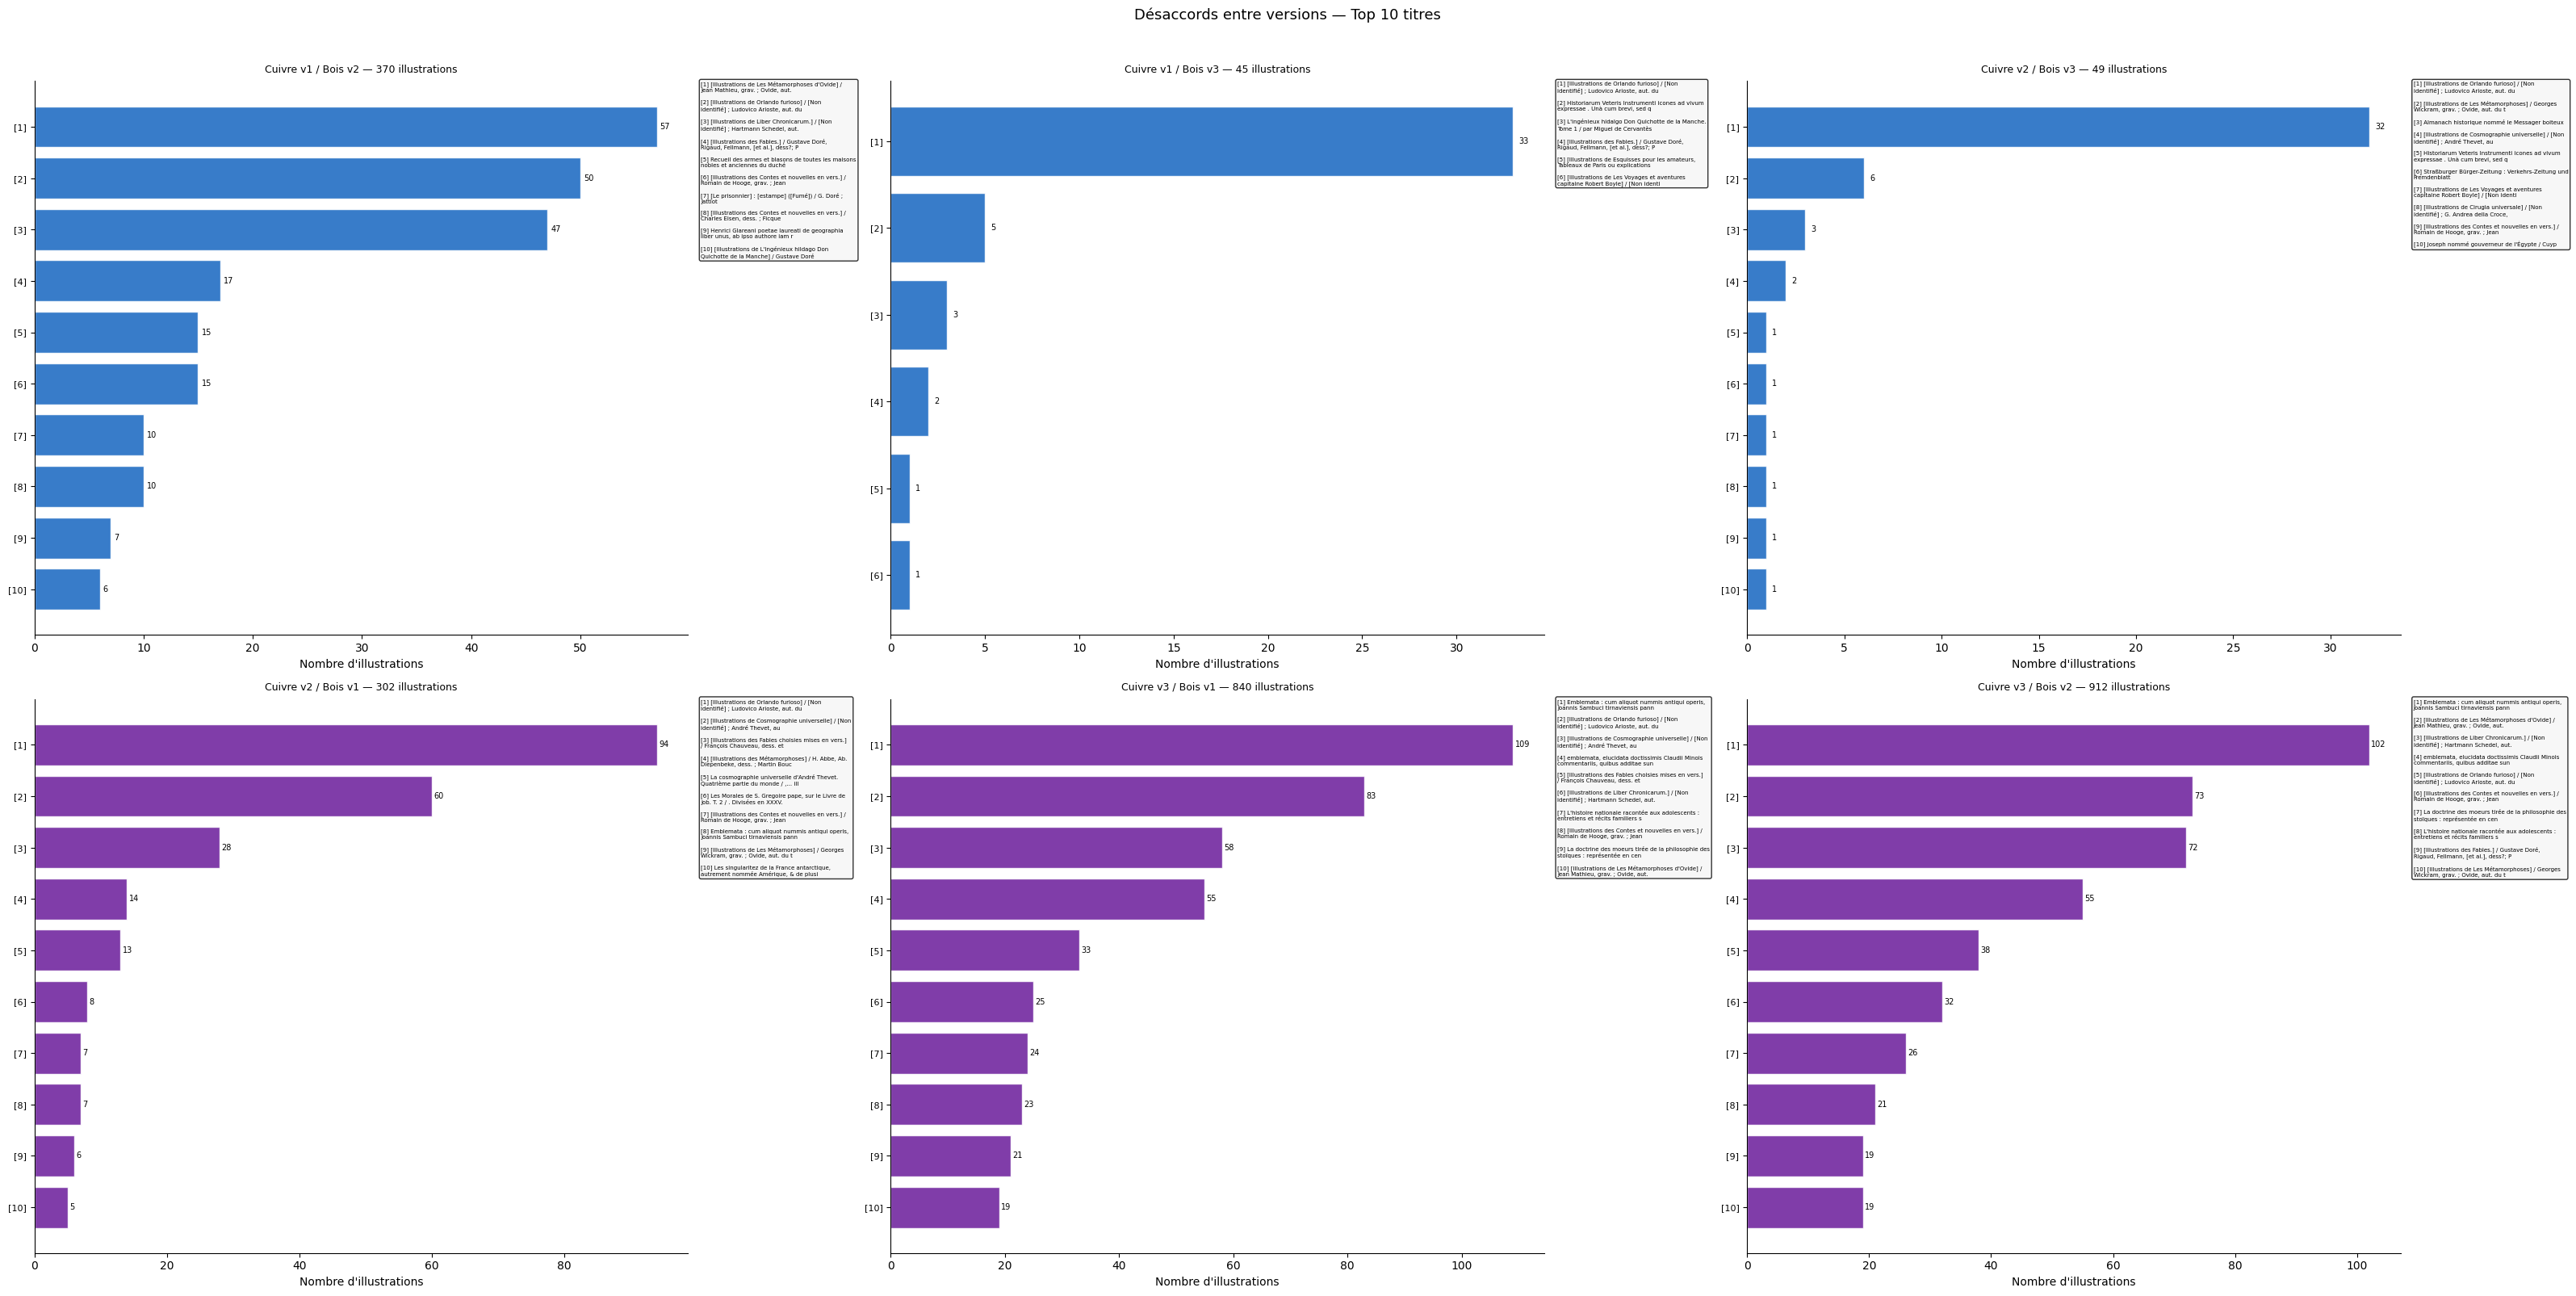

✓ Figure 6 sauvegardée


In [5]:
# ── Désaccords entre les trois versions ──────────────────────
df_v1v2 = df[(df["technique_ia_v1"] == "cuivre") & (df["technique_ia_v2"] == "bois")].copy()
df_v2v1 = df[(df["technique_ia_v2"] == "cuivre") & (df["technique_ia_v1"] == "bois")].copy()
df_v1v3 = df[(df["technique_ia_v1"] == "cuivre") & (df["technique_ia_v3"] == "bois")].copy()
df_v3v1 = df[(df["technique_ia_v3"] == "cuivre") & (df["technique_ia_v1"] == "bois")].copy()
df_v2v3 = df[(df["technique_ia_v2"] == "cuivre") & (df["technique_ia_v3"] == "bois")].copy()
df_v3v2 = df[(df["technique_ia_v3"] == "cuivre") & (df["technique_ia_v2"] == "bois")].copy()

print(f"Cuivre v1 / Bois v2 : {len(df_v1v2)}    Cuivre v2 / Bois v1 : {len(df_v2v1)}")
print(f"Cuivre v1 / Bois v3 : {len(df_v1v3)}    Cuivre v3 / Bois v1 : {len(df_v3v1)}")
print(f"Cuivre v2 / Bois v3 : {len(df_v2v3)}    Cuivre v3 / Bois v2 : {len(df_v3v2)}")

fig, axes = plt.subplots(2, 3, figsize=(32, 16))
fig.suptitle("Désaccords entre versions — Top 10 titres\n", fontsize=13, y=1.0)

paires = [
    (df_v1v2, "Cuivre v1 / Bois v2", "#1565c0"),
    (df_v1v3, "Cuivre v1 / Bois v3", "#1565c0"),
    (df_v2v3, "Cuivre v2 / Bois v3", "#1565c0"),
    (df_v2v1, "Cuivre v2 / Bois v1", "#6a1b9a"),
    (df_v3v1, "Cuivre v3 / Bois v1", "#6a1b9a"),
    (df_v3v2, "Cuivre v3 / Bois v2", "#6a1b9a"),
]

for ax, (df_v, label, color) in zip(axes.flatten(), paires):
    label_full = f"{label} — {len(df_v)} illustrations"
    if len(df_v) == 0:
        ax.text(0.5, 0.5, "Aucun désaccord",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_title(label_full, fontsize=9)
        ax.axis("off")
        continue
    titre_counts  = df_v["titre"].value_counts().head(10)
    labels_courts = [f"[{i+1}]" for i in range(len(titre_counts))]
    bars = ax.barh(
        range(len(titre_counts)),
        titre_counts.values,
        color=color, alpha=0.85, edgecolor="white"
    )
    ax.set_yticks(range(len(titre_counts)))
    ax.set_yticklabels(labels_courts, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Nombre d'illustrations")
    ax.set_title(label_full, fontsize=9, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, titre_counts.values):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=7)
    legende = "\n\n".join(
        [f"[{i+1}] {textwrap.fill(str(t), width=50)}"
         for i, t in enumerate(titre_counts.index)]
    )
    ax.text(1.02, 1.0, legende,
            transform=ax.transAxes,
            fontsize=5, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{DOSSIER_VIZ}/06_desaccords_v1_v2_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure 6 sauvegardée")

In [6]:
titres_celine = [
    "Figures des Histoires de la Sainte Bible",
    "Manon Lescaut",
    "Collection Marolles",
    "Heures",
    "Cupido",
    "sainctes prieres",
    "Recueil des armes",
]

for mot in titres_celine:
    masque = df["titre"].str.contains(mot, case=False, na=False)
    sous_df = df[masque]
    if len(sous_df) == 0:
        print(f"  '{mot}' — absent du corpus actuel")
        continue
    print(f"\n  '{mot}' — {len(sous_df)} illustrations")
    for v in ["v1", "v2", "v3"]:
        rep = sous_df[f"technique_ia_{v}"].value_counts().to_dict()
        print(f"    {v} : {rep}")

  'Figures des Histoires de la Sainte Bible' — absent du corpus actuel

  'Manon Lescaut' — 2 illustrations
    v1 : {'bois': 2}
    v2 : {'bois': 2}
    v3 : {'bois': 2}

  'Collection Marolles' — 17 illustrations
    v1 : {'cuivre': 16, 'bois': 1}
    v2 : {'cuivre': 14, 'bois': 3}
    v3 : {'cuivre': 17}

  'Heures' — 1 illustrations
    v1 : {'bois': 1}
    v2 : {'bois': 1}
    v3 : {'bois': 1}
  'Cupido' — absent du corpus actuel
  'sainctes prieres' — absent du corpus actuel

  'Recueil des armes' — 20 illustrations
    v1 : {'cuivre': 17, 'bois': 3}
    v2 : {'bois': 18, 'cuivre': 2}
    v3 : {'cuivre': 20}


In [7]:
faux_positifs_celine = [
    "Voyages pittoresques",      # lithographie — à exclure
    "Fête dans Tarente",         # manuscrit enluminé
    "Heures de la Vierge",       # bois
    "Histoires de la Sainte Bible",
    "Cupido",
    "presentes Heures",
    "Nouvelle Histoire de la France",  # cuivre selon Céline
    "Musee de peinture",         # doute de Céline
]

for mot in faux_positifs_celine:
    masque = df["titre"].str.contains(mot, case=False, na=False)
    sous_df = df[masque]
    if len(sous_df) == 0:
        print(f"  '{mot}' — absent")
        continue
    print(f"\n  '{mot}' — {len(sous_df)} illustrations")
    for v in ["v1", "v2", "v3"]:
        rep = sous_df[f"technique_ia_{v}"].value_counts().to_dict()
        print(f"    {v} : {rep}")


  'Voyages pittoresques' — 3 illustrations
    v1 : {'bois': 2, 'cuivre': 1}
    v2 : {'bois': 3}
    v3 : {'bois': 2, 'cuivre': 1}
  'Fête dans Tarente' — absent
  'Heures de la Vierge' — absent
  'Histoires de la Sainte Bible' — absent
  'Cupido' — absent
  'presentes Heures' — absent
  'Nouvelle Histoire de la France' — absent
  'Musee de peinture' — absent


Dossier courant : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir/notebooks/analyse


In [17]:
print("Valeurs de la colonne 'technique' :\n")
print(df["technique"].value_counts())

Valeurs de la colonne 'technique' :

technique
estampe         7079
photographie    1186
impression        24
peinture           6
dessin             5
Name: count, dtype: int64


In [11]:
import pandas as pd

# ── Comparaison filtré (estampes) vs complet (toutes techniques) ──
df_complet = pd.read_csv("../../resultats/csv/salomon_enrichi_segmente.csv")
df_estampe = df_complet[df_complet["technique"] == "estampe"].copy()

def stats_version(d, nom):
    # Accord des 3 versions sur cuivre, dédupliqué par illustration
    accord = d[(d["technique_ia_v1"] == "cuivre") &
               (d["technique_ia_v2"] == "cuivre") &
               (d["technique_ia_v3"] == "cuivre")].drop_duplicates(subset=["link"])

    # Désaccords, dédupliqués
    desaccord = d[
        ~((d["technique_ia_v1"] == d["technique_ia_v2"]) &
          (d["technique_ia_v2"] == d["technique_ia_v3"]))
    ].drop_duplicates(subset=["link"])

    print(f"── {nom} ──")
    print(f"  Illustrations totales (dédupliquées) : {d.drop_duplicates(subset=['link']).shape[0]}")
    print(f"  Accord cuivre v1+v2+v3 : {len(accord)} illustrations / {accord['titre'].nunique()} titres")
    print(f"  Désaccords             : {len(desaccord)} illustrations / {desaccord['titre'].nunique()} titres")
    print()
    return accord, desaccord

print("=" * 60)
print("COMPARAISON DES DEUX VERSIONS DE VALIDATION")
print("=" * 60 + "\n")

acc_c, des_c = stats_version(df_complet, "COMPLET (toutes techniques)")
acc_e, des_e = stats_version(df_estampe, "FILTRÉ (estampes uniquement)")

# Ce que le filtre estampe retire
print("── Impact du filtre estampe ──")
print(f"  Titres cuivre perdus : {acc_c['titre'].nunique() - acc_e['titre'].nunique()}")
print(f"  Illustrations cuivre perdues : {len(acc_c) - len(acc_e)}")

# Répartition des techniques dans l'accord cuivre du complet
print("\n── Techniques des illustrations 'accord cuivre' (version complète) ──")
print(acc_c["technique"].value_counts())

COMPARAISON DES DEUX VERSIONS DE VALIDATION

── COMPLET (toutes techniques) ──
  Illustrations totales (dédupliquées) : 2290
  Accord cuivre v1+v2+v3 : 457 illustrations / 156 titres
  Désaccords             : 564 illustrations / 219 titres

── FILTRÉ (estampes uniquement) ──
  Illustrations totales (dédupliquées) : 1882
  Accord cuivre v1+v2+v3 : 261 illustrations / 121 titres
  Désaccords             : 430 illustrations / 184 titres

── Impact du filtre estampe ──
  Titres cuivre perdus : 35
  Illustrations cuivre perdues : 196

── Techniques des illustrations 'accord cuivre' (version complète) ──
technique
estampe         261
photographie    192
impression        4
Name: count, dtype: int64
